# Multi-Layer Perceptron
### Gamma/Neutron Discrimination 

--- 

- Workflow based on R. S. Molina, I. R. Morales, M. L. Crespo, V. G. Costa, S. Carrato and G. Ramponi, "An End-to-End Workflow to Efficiently Compress and Deploy DNN Classifiers on SoC/FPGA", in IEEE Embedded Systems Letters, vol. 16, no. 3, pp. 255-258, Sept. 2024, doi: 10.1109/LES.2023.3343030.

- Code adapted from the official repository of "An End-to-End Workflow to Efficiently Compress and Deploy DNN Classifiers on SoC/FPGA"

- Using open dataset from: https://doi.org/10.5281/zenodo.8037058

----

## Import libraries


In [ ]:
import os
import sys

# Path
sys.path.append(os.path.abspath(".."))

# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

from numpy import array

import subprocess

from pathlib import Path
import shutil

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras import backend as K
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
# from tensorflow.keras.layers import Dense, Activation, Input, Dropout, Normalization
from tensorflow.keras.models import *
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l1, l2

# Model optimization
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.sparsity.keras import (
    prune,
    pruning_callbacks,
    pruning_schedule
)
from tensorflow_model_optimization.sparsity.keras import strip_pruning, prune_low_magnitude


# QKeras (Quantization)
from qkeras import *
import tensorflow as tf
from qkeras import QDense, QActivation

# Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Dataset split
from sklearn.model_selection import train_test_split

# HLS4ML
import hls4ml

# Reproducibility
tf.random.set_seed(42)

# Clear sessions
K.clear_session()
tf.keras.backend.clear_session()

import sys
sys.path.append(os.path.abspath('../../'))
from common.notebook_utils.distillationClassKeras import Distiller
from common.notebook_utils.utils import report_classifier

2026-04-01 17:33:41.998688: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-01 17:33:42.042673: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-01 17:33:42.817286: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/tools/anaconda3/envs/neuralEnv/lib/python3.10/site-packages/hls4ml/converters/__init__.py:27: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


### Enable GPU 

In [3]:
#  GPU 
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'

import tensorflow as tf
print("GPUs: ", len(tf.config.experimental.list_physical_devices('GPU')))

import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

    except RuntimeError as e:
        print(e)

GPUs:  1


2026-04-01 17:33:44.047022: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 17:33:44.089789: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 17:33:44.090100: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

## Auxiliar functions

In [4]:
# Function to define the training and testing datasets

def preproc_dataset_(signal_dfN, signal_dfG):
    
    # Label in csv file corresponds to the signal class
    _LABEL_COLUMN = 'class'
    
    # Define training and testing datasets
    dfTest = pd.DataFrame()
    dfTrain = pd.DataFrame()
    
    # Shuffle datasets
    signal_dfN = shuffle(signal_dfN)
    signal_dfG = shuffle(signal_dfG)
    
    # Concatenate datasets
    signal_df = pd.concat([signal_dfN, signal_dfG])
    
    # Split training and testing datasets
    for k in range(0,2):
     
        df2 = signal_df[signal_df[_LABEL_COLUMN].isin([k])]
        
        df_tr = df2[:10000]
        df_t = df2[10001:10900]
        
        dfTrain = pd.concat([df_tr, dfTrain])   
        dfTest = pd.concat([df_t, dfTest])
        
    
    return dfTrain, dfTest

---

## Dataset

In [5]:
# Define path to the dataset for training

PATH = '../00.datasets/'

GAMMA_DATASET_FILE = PATH + 'gamma_label.csv'
NEUTRON_DATASET_FILE = PATH + 'neutron_label.csv'

TEST_DATASET_FILE = PATH + 'test.csv'

In [6]:
# Load datasets in Pandas data frame 

dfGamma = pd.read_csv(GAMMA_DATASET_FILE)
dfNeutron = pd.read_csv(NEUTRON_DATASET_FILE)
dfTestGN = pd.read_csv(TEST_DATASET_FILE)

In [7]:
# Pre-processing dataset for training 
df_train, dfTest = preproc_dataset_(dfNeutron, dfGamma)


In [8]:
df_train_ = df_train.pop('class')
dfTest_ = dfTest.pop('class')

# One-hot encoder
le = LabelEncoder()
y = le.fit_transform(df_train_)
y = to_categorical(df_train_, 2)

le = LabelEncoder()
y_test = le.fit_transform(dfTest_)
y_test = to_categorical(dfTest_, 2)

# Split training dataset into training and validation
x_train, x_val, y_train, y_val = train_test_split(df_train, y, test_size=0.2, random_state=42)

---

### Load Model

In [9]:

from qkeras.utils import _add_supported_quantized_objects

co = {}
_add_supported_quantized_objects(co)

model = tf.keras.models.load_model('../01.training/models/studentModel_GN.h5', custom_objects=co)

2026-04-01 17:33:44.746027: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x2613ba30 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-04-01 17:33:44.746051: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): Host, Default Version
2026-04-01 17:33:44.746280: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 17:33:44.746506: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
20

----


## Integration with a hardware synthesis tool for ML

In [ ]:
# PATH Vitis HLS installation
os.environ['PATH'] = '/tools/Xilinx/Vitis_HLS/2024.1/bin:' + os.environ['PATH']
os.environ['PATH']

'/tools/Xilinx/Xilinx2024/Vitis_HLS/2024.1/bin:/tools/anaconda3/envs/neuralEnv/bin:/tools/anaconda3/condabin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin'

### hls4ml

**hls4ml** is a Python package developed for converting machine learning (ML) models into HLS (High-Level Synthesis) projects, enabling deployment of ML-based inference on hardware like FPGAs. More details can be found at [hls4ml documentation](https://fastmachinelearning.org/hls4ml/).

The user can control several options related to the model, including:

- **Precision:** Define the precision of the calculations in your model (e.g., fixed-point or floating-point representation).

- **Dataflow/Resource Reuse:** Control the level of parallelism or streaming in model implementations, with varying degrees of pipelining.

An HLS configuration should be created using the function `hls4ml.utils.config_from_keras_model(kerasModel, granularity)`, where kerasModel is the pre-trained model you want to implement on an FPGA, and granularity determines the configuration level. The two possible values for granularity are:

- 'model': The same configuration applies to the entire model (e.g., all layers use 16-bit fixed-point precision).

- 'name': Layer-specific configurations can be applied (e.g., the input layer can be defined in 8-bit fixed-point precision, while the second layer is set to 16-bit fixed-point precision).

In [ ]:

# Generate an hls4ml configuration dictionary from the Keras model.
# - granularity='name' : allows per-layer configuration by layer name
# - default_precision  : sets the default fixed-point format for all layers
#     fixed<24,20> → 24-bit total width, 20 integer bits, 4 fractional bits
hls_config = hls4ml.utils.config_from_keras_model(
    model,
    granularity='name',
    default_precision='fixed<24,20>'
)

# --- Global Model-Level Settings ---

# ReuseFactor=8  : hardware resources are reused 8 times across computations
# RoundingMode   : AP_RND (Round to nearest): more accurate than truncation
# SaturationMode : AP_SAT (Saturate): clamps values to min/max, prevents overflow artifacts
hls_config['Model']['ReuseFactor']    = 8
hls_config['Model']['RoundingMode']   = 'AP_RND'
hls_config['Model']['SaturationMode'] = 'AP_SAT'

# --- Layer-Specific Settings ---

# Use 'Stable' softmax strategy for numerical stability
# Override the global ReuseFactor for this specific layer
hls_config['LayerName']['outputActivation']['Strategy']    = 'Stable'
hls_config['LayerName']['outputActivation']['ReuseFactor'] = 16

Interpreting Model
Topology:
Layer name: inputLayer, layer type: InputLayer, input shapes: [[None, 161]], output shape: [None, 161]
Layer name: fc1, layer type: QDense, input shapes: [[None, 161]], output shape: [None, 5]
Layer name: relu0, layer type: Activation, input shapes: [[None, 5]], output shape: [None, 5]
Layer name: fc2, layer type: QDense, input shapes: [[None, 5]], output shape: [None, 4]
Layer name: relu1, layer type: Activation, input shapes: [[None, 4]], output shape: [None, 4]
Layer name: fc3, layer type: QDense, input shapes: [[None, 4]], output shape: [None, 4]
Layer name: relu2, layer type: Activation, input shapes: [[None, 4]], output shape: [None, 4]
Layer name: fc4, layer type: QDense, input shapes: [[None, 4]], output shape: [None, 5]
Layer name: relu3, layer type: Activation, input shapes: [[None, 5]], output shape: [None, 5]
Layer name: fc5, layer type: QDense, input shapes: [[None, 5]], output shape: [None, 3]
Layer name: relu4, layer type: Activation, input s

In [ ]:
# Directory path where the HLS (High-Level Synthesis) project will be generated.
# hls4ml translates the neural network into synthesizable RTL code for FPGA deployment.
PATH_HLS_PROJECT = '../02.hls4ml/output/'

# Create configuration for Vitis HLS as backend.
cfg = hls4ml.converters.create_config(backend='Vitis')
# HLSConfig correspond to the configuration created in hls_config 
cfg['IOType']     = 'io_stream'   
cfg['HLSConfig']  = hls_config
# Model to be converted
cfg['KerasModel'] = model
# Folder where the HLS project will be created
cfg['OutputDir']  = PATH_HLS_PROJECT
# FPGA part 
cfg['Part'] = 'xczu3eg-sfvc784-2-e'  
  
  

Interpreting Model
Topology:
Layer name: inputLayer, layer type: InputLayer, input shapes: [[None, 161]], output shape: [None, 161]
Layer name: fc1, layer type: QDense, input shapes: [[None, 161]], output shape: [None, 5]
Layer name: relu0, layer type: Activation, input shapes: [[None, 5]], output shape: [None, 5]
Layer name: fc2, layer type: QDense, input shapes: [[None, 5]], output shape: [None, 4]
Layer name: relu1, layer type: Activation, input shapes: [[None, 4]], output shape: [None, 4]
Layer name: fc3, layer type: QDense, input shapes: [[None, 4]], output shape: [None, 4]
Layer name: relu2, layer type: Activation, input shapes: [[None, 4]], output shape: [None, 4]
Layer name: fc4, layer type: QDense, input shapes: [[None, 4]], output shape: [None, 5]
Layer name: relu3, layer type: Activation, input shapes: [[None, 5]], output shape: [None, 5]
Layer name: fc5, layer type: QDense, input shapes: [[None, 5]], output shape: [None, 3]
Layer name: relu4, layer type: Activation, input s

Done


bash: /tools/anaconda3/envs/neuralEnv/lib/libtinfo.so.6: no version information available (required by bash)


In [ ]:
# Convert the Keras model to an HLS model using the configuration
hls_model = hls4ml.converters.keras_to_hls(cfg)

# Compile the HLS model for simulation/verification
hls_model.compile()

### Keras vs HLS model evaluation

In [13]:

if y_test.ndim == 2 and y_test.shape[1] > 1:
    y_true = y_test.argmax(axis=1)
else:
    y_true = np.array(y_test).ravel()

n_features = model.input_shape[1]
x_test = np.ascontiguousarray(dfTest.to_numpy(dtype=np.float32).reshape(-1, n_features))

# Keras model predictions
y_pred_keras = model.predict(x_test, batch_size=1024, verbose=0)   

# HLS-based model predictions
y_pred_hls = hls_model.predict(x_test)

y_hat_keras = y_pred_keras.argmax(axis=1)
y_hat_hls = y_pred_hls.argmax(axis=1)

acc_ker = (y_hat_keras == y_true).mean()
acc_hls = (y_hat_hls == y_true).mean()
print(f'Accuracy Keras (model): {acc_ker:.4f} | Accuracy HLS: {acc_hls:.4f}')


Accuracy Keras (model): 0.9900 | Accuracy HLS: 0.9900


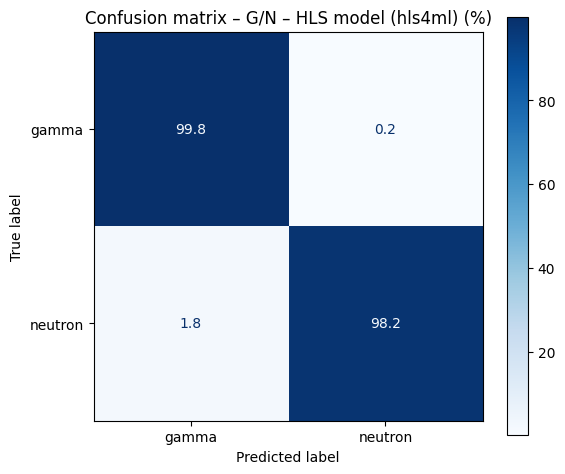

In [20]:
figs, aucs, metrics = report_classifier(
    history=None,
    y_true=np.argmax(y_test, axis=1),
    y_proba=hls_model.predict(x_test),
    class_names=['gamma', 'neutron'],
    model_name="G/N – HLS model (hls4ml)",
    show=False
)

display(figs["cm"])

In [19]:
print(y_test.shape, y_test.dtype)
print(y_pred_keras.shape)

(1798, 2) float32
(1798, 2)


In [ ]:
# Synthesizes the HLS project and reports key metrics: latency and resource usage.
hls_model.build(csim=False, export=False)

/bin/bash: /tools/anaconda3/envs/neuralEnv/lib/libtinfo.so.6: no version information available (required by /bin/bash)


/bin/bash: /tools/anaconda3/envs/neuralEnv/lib/libtinfo.so.6: no version information available (required by /bin/bash)
/bin/bash: /tools/anaconda3/envs/neuralEnv/lib/libtinfo.so.6: no version information available (required by /bin/bash)

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.1 (64-bit)
  **** SW Build 5069499 on May 21 2024
  **** IP Build 5075265 on Wed May 22 21:45:21 MDT 2024
  **** SharedData Build 5076995 on Wed May 22 18:29:18 MDT 2024
  **** Start of session at: Mon Mar 30 22:53:06 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Xilinx2024/Vitis_HLS/2024.1/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] For user 'ro' on host 'mareKaleido' (Linux_x86_64 version 5.15.0-139-generic) on Mon Mar 30 22:53:08 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 20.04.6 LTS
INFO: [HLS 200-10] In directory '/home/ro/kaleido/repo/github/aup-zu3-am

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '4.329',
  'BestLatency': '1097',
  'WorstLatency': '1097',
  'IntervalMin': '1050',
  'IntervalMax': '1050',
  'BRAM_18K': '2',
  'DSP': '70',
  'FF': '12760',
  'LUT': '32661',
  'URAM': '0',
  'AvailableBRAM_18K': '432',
  'AvailableDSP': '360',
  'AvailableFF': '141120',
  'AvailableLUT': '70560',
  'AvailableURAM': '0'}}

Once the hls4ml project has been synthesized and the hardware metrics have been reviewed (latency, throughput, LUT/FF/DSP/BRAM utilization), the next step is to enable FPGA integration.

To achieve this, an AXI-based wrapper must be added around the generated HLS model, typically including AXI4-Stream interfaces for data movement and AXI-Lite for control.

This wrapper allows the design to be driven by a DMA engine or other AXI infrastructure in the FPGA system, enabling high-performance inference from the processing system or external data sources.

In [ ]:
# Add AXI-Stream support 

# Copy the .cpp and .h files that contain the AXI-based wrapper into the firmware/ directory of the hls4ml project. 
# These files provide the AXI4-Stream and AXI-Lite interfaces required for DMA-driven inference on the FPGA.
shutil.copy("../03.hls/myproject_gn_accel.cpp", os.path.join(PATH_HLS_PROJECT, "firmware"))
shutil.copy("../03.hls/myproject_gn_accel.h", os.path.join(PATH_HLS_PROJECT, "firmware"))


'../02.hls4ml/output/firmware/myproject_gn_accel.h'

The *build_accel.tcl* script defines the complete HLS build process: itcreates a clean Vitis HLS project, adds the hls4ml sources plus the AXI/DMA wrapper, configures the FPGA part, sets the clock, and triggers synthesis. Also,  it generates a fully packaged IP core that can be directly imported into Vivado.

In [20]:
# Copy tcl file 
shutil.copy("../03.hls/build_accel.tcl", PATH_HLS_PROJECT)

'../02.hls4ml/output/build_accel.tcl'

The TCL script is executed from Python using subprocess.run.

This produces a fully synthesized IP block inside: \<project\>/myproject_accel_prj/solution1/impl/ip/*


In [ ]:
# Execute tcl file to generate the corresponding HLS project + IP core

PROJ_DIR = Path(PATH_HLS_PROJECT)

res = subprocess.run(
    ["vitis_hls", "-f", "build_accel.tcl"],
    cwd=PROJ_DIR,                      
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print("Return code:", res.returncode)
print(res.stdout)


From this point, once the IP core has been generated, you can create the corresponding hardware in Vivado, which will ultimately be used in the PYNQ framework.

Open Vivado and follow the steps in the wiki to continue the workflow.

---

This work was supported in part by the [AMD University Program](https://www.amd.com/en/corporate/university-program.html) 